# EDA Time Series Tourism

In [5]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Carga de Datos

In [9]:
df = pd.read_csv("../data/processed/master_tourism_series.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     86 non-null     str    
 1   Ocupacion_Caribe         86 non-null     float64
 2   Hab_Disponibles_Caribe   86 non-null     float64
 3   Hab_Ocupadas_Caribe      86 non-null     float64
 4   Ingreso_Real_Var_Caribe  74 non-null     float64
dtypes: float64(4), str(1)
memory usage: 4.3 KB


Vemos que estan las columnas de la serie de tiempo que importan que son la Fecha, La Ocupacion, Hab Disponibles, Ocupadas y la Variacion del Ingreso Real

# ¿Por qué son importantes estas features parael analisis de estas series de tiempo con el objetivo de predecir el turismo caibeño?

1. El Latido del Sector: Ocupacion_Caribe *(Proviene de la pestaña 3.2 de la EMA.)*

Es el indicador de éxito por excelencia. Un modelo que predice la ocupación permite a los hoteles decidir si deben lanzar promociones (cuando la ocupación proyectada es baja) o subir precios (cuando se espera un lleno total).

2. Oferta vs. Demanda: Hab_Disponibles y Hab_Ocupadas *(Extraídas de la pestaña 5 de la encuesta.)*

La ocupación es un porcentaje, pero estas columnas nos dan números absolutos.Si las Hab_Disponibles aumentan y la ocupación se mantiene, significa que el mercado está creciendo (hay nuevos hoteles).

3. Salud Financiera: Ingreso_Real_Var_Caribe *(Pestaña 1.1 de la EMA.)*

No siempre más gente significa más dinero. Si la ocupación sube pero el ingreso real baja, el sector está perdiendo poder adquisitivo o bajando precios agresivamente para atraer turistas. Para nuestro modelo (como un LSTM o Prophet), esta variable ayuda a entender si la demanda es "de valor" o solo de volumen.



In [12]:
# Convertir Date a datetime si aún no lo has hecho
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [20]:
display(df.head(20))

,Date,Ocupacion_Caribe,Hab_Disponibles_Caribe,Hab_Ocupadas_Caribe,Ingreso_Real_Var_Caribe
0,2019-01-01,51.009846,101.113050,106.351823,NaN
1,2019-02-01,45.726525,91.647809,86.411990,NaN
2,2019-03-01,49.468632,100.980547,103.003347,NaN
3,2019-04-01,44.551978,98.113584,90.132176,NaN
4,2019-05-01,41.651362,101.419910,87.103609,NaN
5,2019-06-01,46.824913,99.218714,95.797526,NaN
6,2019-07-01,48.488852,103.023690,103.006047,NaN
7,2019-08-01,51.826227,102.911190,109.975493,NaN
8,2019-09-01,48.199832,99.677148,99.066051,NaN
9,2019-10-01,47.334796,102.106793,99.659536,NaN


# Visualizaciones

In [14]:
import plotly.graph_objects as go
import plotly.express as px

fig1 = px.line(df, x='Date', y='Ocupacion_Caribe', 
              title='<b>Evolution of Hotel Occupancy in the Caribbean</b>',
              labels={'Ocupacion_Caribe': 'Occupancy %', 'Date': 'Month'},
              template='plotly_white')

fig1.update_traces(line_color='#0077b6', line_width=3)
fig1.add_vrect(x0="2020-03-01", x1="2020-07-01", 
              fillcolor="red", opacity=0.1, layer="below", line_width=0,
              annotation_text="COVID-19 Impact", annotation_position="top left")

fig1.show()

In [17]:
fig2 = go.Figure()

# Línea de Ocupación
fig2.add_trace(go.Scatter(x=df['Date'], y=df['Ocupacion_Caribe'],
                         name='Occupancy %', line=dict(color='#0077b6', width=3)))

# Barras de Variación de Ingresos (Eje secundario)
fig2.add_trace(go.Bar(x=df['Date'], y=df['Ingreso_Real_Var_Caribe'],
                     name='Real Income Var %', marker_color='#efad4d', 
                     opacity=0.6, yaxis='y2'))

fig2.update_layout(
    title='<b>Occupancy vs. Real Income Variation</b>',
    xaxis=dict(title='Month'),
    # AQUÍ ESTÁ EL CAMBIO: title ahora es un diccionario que contiene el texto y la fuente
    yaxis=dict(
        title=dict(text='Occupancy %', font=dict(color='#0077b6')), 
        tickfont=dict(color='#0077b6')
    ),
    yaxis2=dict(
        title=dict(text='Income Var %', font=dict(color='#efad4d')), 
        tickfont=dict(color='#efad4d'),
        overlaying='y', 
        side='right'
    ),
    legend=dict(x=0.01, y=0.98),
    template='plotly_white'
)

fig2.show()

In [18]:
fig3 = go.Figure()

fig3.add_trace(go.Scatter(x=df['Date'], y=df['Hab_Disponibles_Caribe'],
                         fill='tozeroy', name='Available Rooms Index',
                         line_color='#caf0f8'))

fig3.add_trace(go.Scatter(x=df['Date'], y=df['Hab_Ocupadas_Caribe'],
                         fill='tonexty', name='Occupied Rooms Index',
                         line_color='#023e8a'))

fig3.update_layout(title='<b>Hotel Capacity vs. Actual Demand</b>',
                  xaxis_title='Month', yaxis_title='Index Value',
                  template='plotly_white')

fig3.show()

Procesando descomposición para: Ocupacion_Caribe (Modelo: multiplicative)


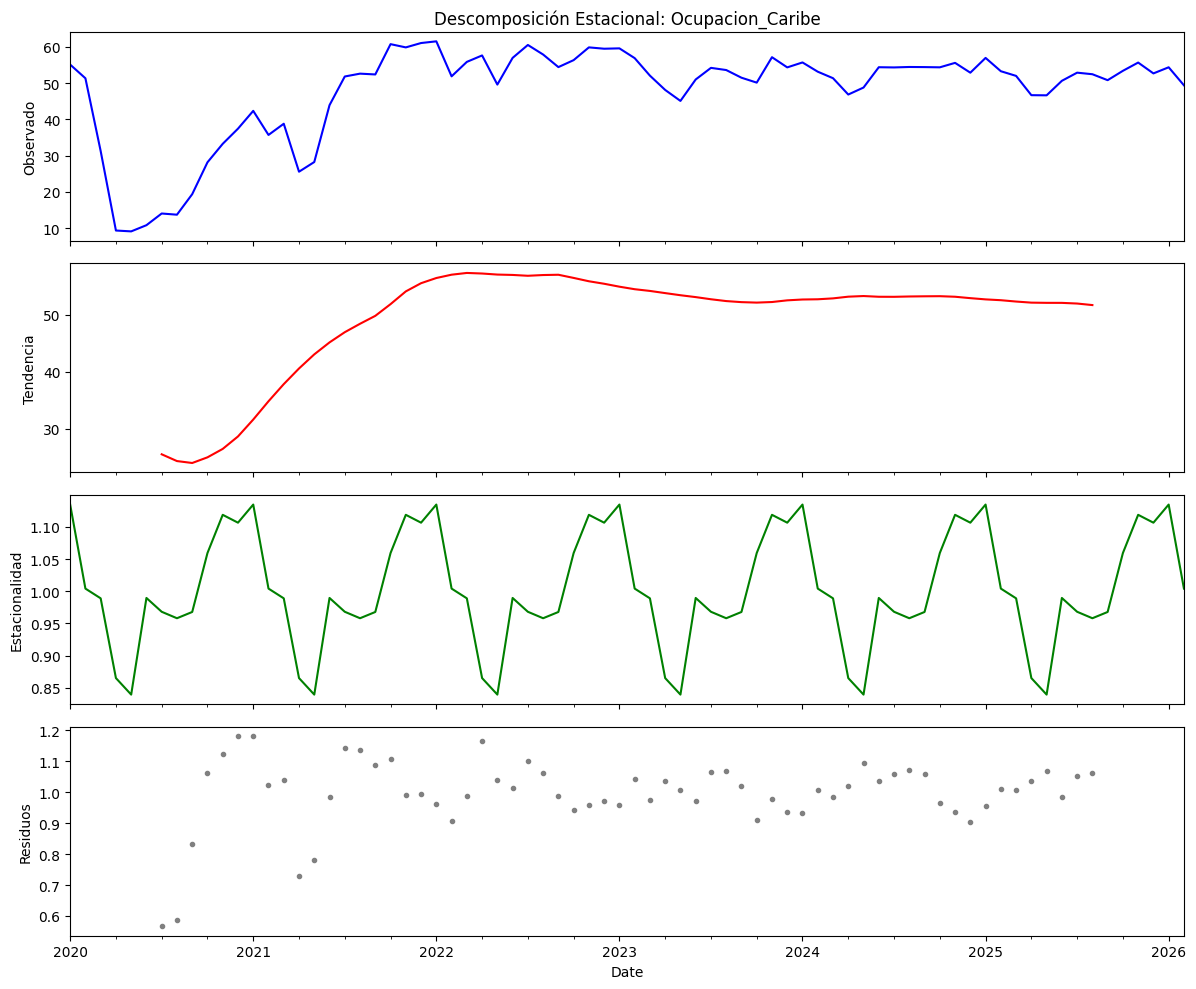

Procesando descomposición para: Hab_Ocupadas_Caribe (Modelo: multiplicative)


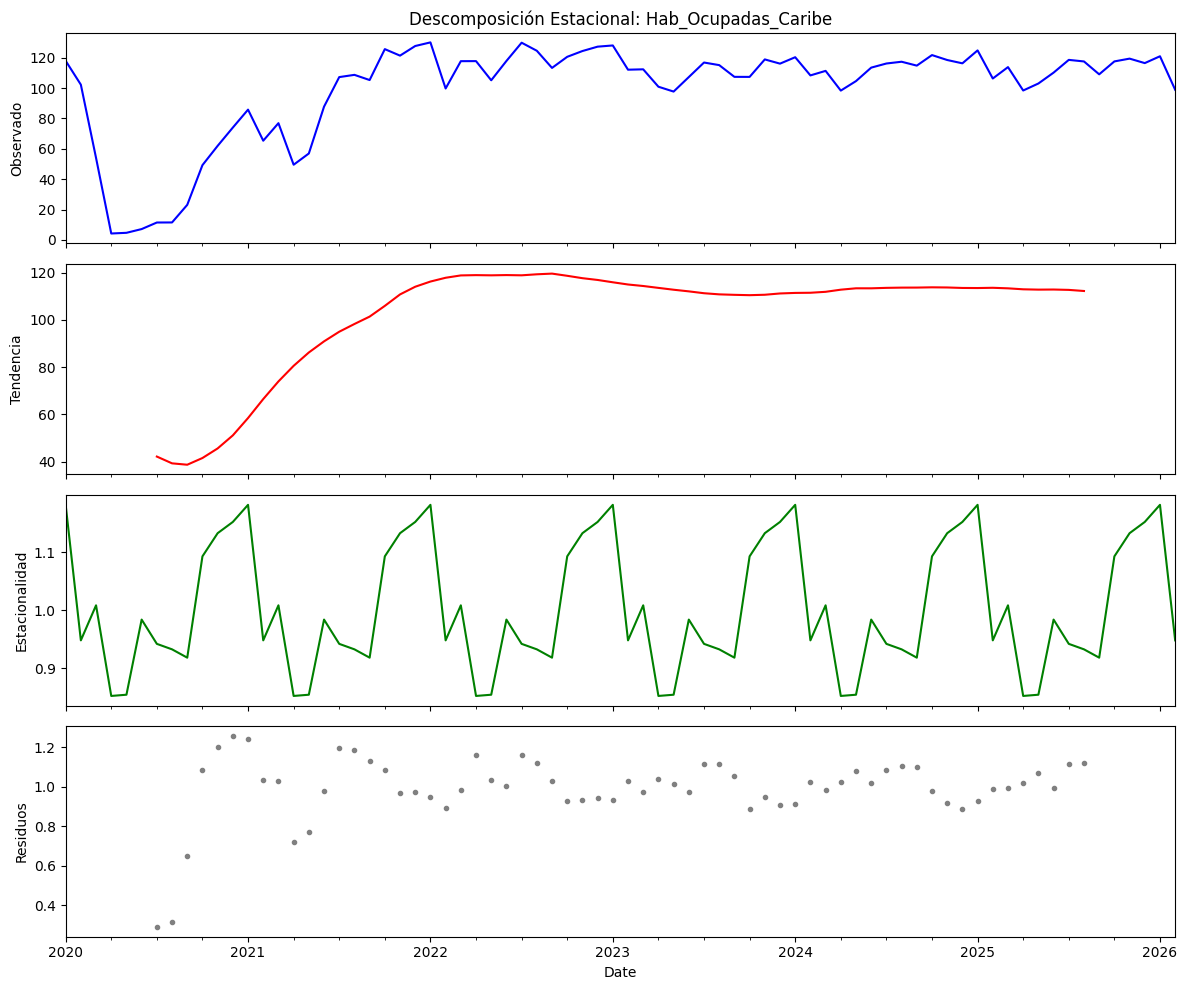

Procesando descomposición para: Hab_Disponibles_Caribe (Modelo: additive)


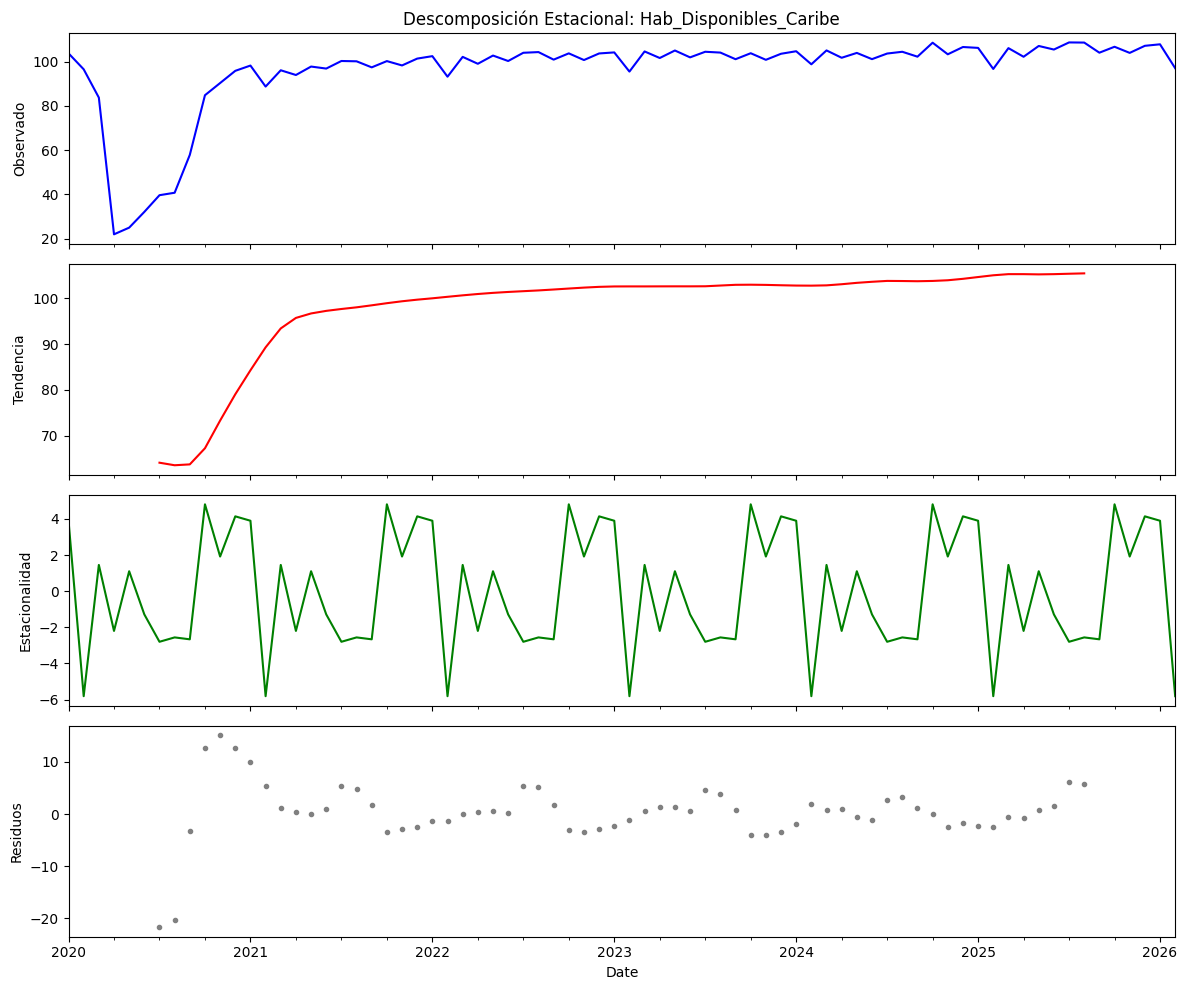

Procesando descomposición para: Ingreso_Real_Var_Caribe (Modelo: additive)


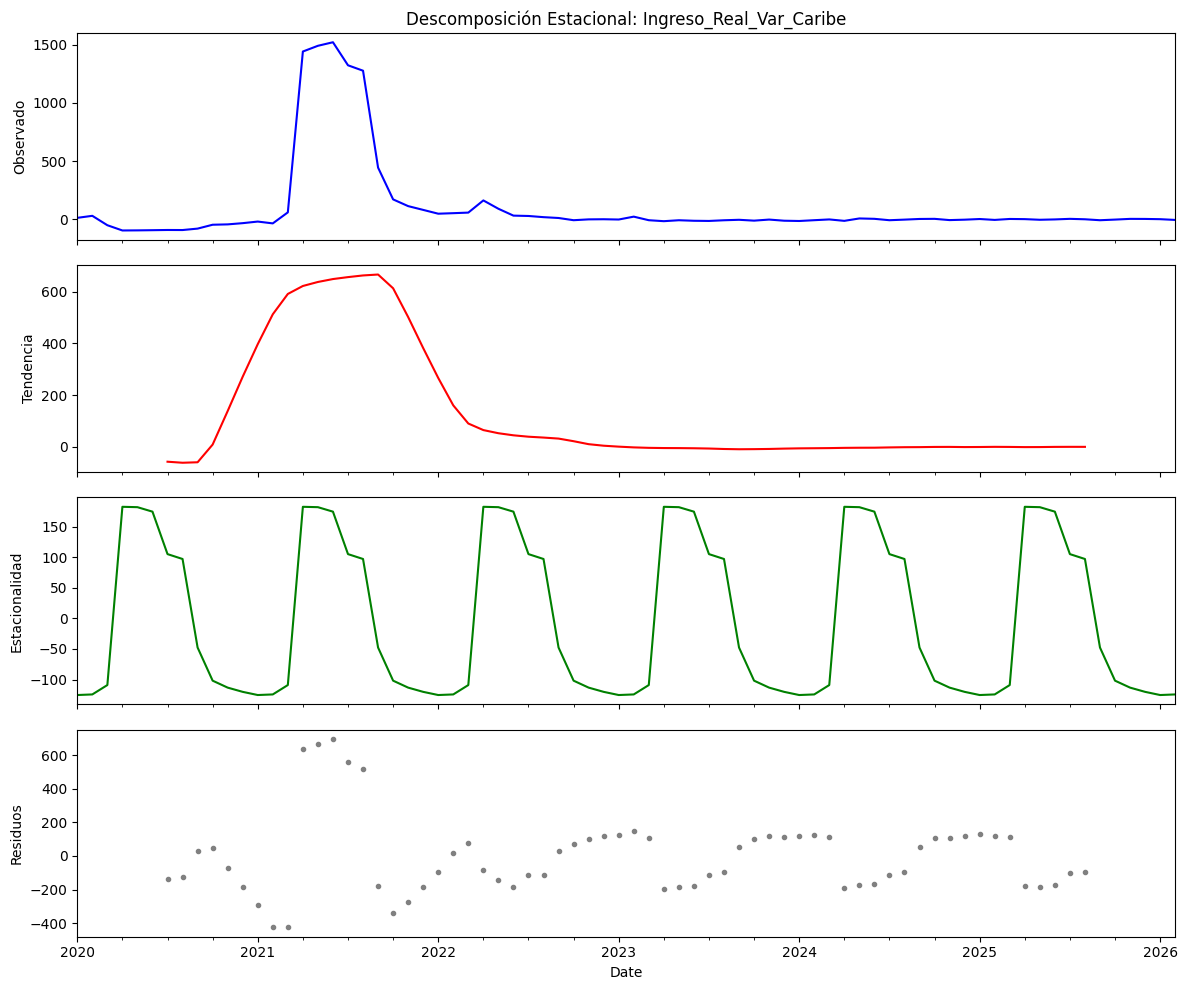

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Cargar el dataset procesado
df = pd.read_csv('../data/processed/master_tourism_series.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- LIMPIEZA DE DATOS (Solución al ValueError) ---
# Interpolación lineal para rellenar huecos sin romper la frecuencia
df_clean = df.interpolate(method='linear')

# El modelo multiplicativo no acepta ceros (común en 2020). 
# Reemplazamos ceros por un valor ínfimo para permitir el cálculo.
df_clean = df_clean.replace(0, 0.00001)

# Eliminar nulos remanentes en los extremos (si los hay)
df_clean = df_clean.dropna()
# --------------------------------------------------

series_to_analyze = {
    'Ocupacion_Caribe': 'multiplicative',
    'Hab_Ocupadas_Caribe': 'multiplicative',
    'Hab_Disponibles_Caribe': 'additive',
    'Ingreso_Real_Var_Caribe': 'additive'
}

def perform_decomposition(df, column, model_type):
    print(f"Procesando descomposición para: {column} (Modelo: {model_type})")
    
    # Realizar la descomposición (periodo=12 para datos mensuales)
    try:
        result = seasonal_decompose(df[column], model=model_type, period=12)
        
        # Configurar la visualización
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
        
        result.observed.plot(ax=ax1, color='blue')
        ax1.set_ylabel('Observado')
        ax1.set_title(f'Descomposición Estacional: {column}')
        
        result.trend.plot(ax=ax2, color='red')
        ax2.set_ylabel('Tendencia')
        
        result.seasonal.plot(ax=ax3, color='green')
        ax3.set_ylabel('Estacionalidad')
        
        result.resid.plot(ax=ax4, color='gray', style='.')
        ax4.set_ylabel('Residuos')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error al procesar {column}: {e}")

# 2. Ejecutar el análisis usando el dataframe LIMPIO
for col, model in series_to_analyze.items():
    if col in df_clean.columns:
        perform_decomposition(df_clean, col, model)
    else:
        print(f"Advertencia: La columna {col} no se encuentra en el dataset.")

# Analisis Final

1. Para la serie de tiempo de *ocupacion* vemos que existe un fuerte componente estacional y ademas tiene una tendencia alcista y ademas con memoria por lo que se queda arriba 

2. Para al serie de Habitaciones ocupadas se ve que claramente hay un fuerte componente estacional y ademas la tendencia tambien tiene memoria pero tanto en la serie de tiempo 1 y 2 se ve que la volatilidad non es fierte por lo que se descarta un GARCH o un GARCH con btightness 

3. Para la serie de tiempo de Habitaciones Disponibles tiene casi el mismo comportamiento que el de las habitaciones ocupadas

4. Para la serie de tiempo de Variacion de ingreso real se ve el efecto COVID-19 que hizo que los ingresos reales de la gente bajaran fuertemente y se recuperaran y quedaran al mismo nivel probablemente tendremos que usar ANALISIS DE SERIES DE TIEMPO INTERRUMPIDAS con estimadores de estados de espacio bayesianos usando *causal impact* y ademas *OLS*.